In [14]:
import simulation_2MQRM as t
import numpy as np
import qutip as qt
import scipy as sp
import matplotlib.pyplot as plt
import torch
from mpmath import mpf
from mpmath import mp
import mpmath
import pandas as pd
import datashader as ds
import datashader.transfer_functions as tf
from datashader import reductions as rd
import matplotlib.pyplot as plt
import matplotlib.colorbar as mcolorbar
import matplotlib.colors as mcolors
import colorcet as cc
import pickle
from pathlib import Path
import warnings

In [15]:
df = pd.read_csv("qfidataframe.csv")
df

,Temp,QFI
0,0.000050,0.000000e+00
1,0.000051,7.877257e-09
2,0.000051,7.501527e-09
3,0.000052,0.000000e+00
4,0.000053,0.000000e+00
...,...,...
6406395,9.640088,9.847435e-05
6406396,9.758596,9.377504e-05
6406397,9.878560,8.929989e-05
6406398,10.000000,8.503821e-05


In [16]:
warnings.filterwarnings("ignore", message=r"^numpy\.core\.numeric is deprecated", category=DeprecationWarning)
with Path("avgqfi.pkl").open("rb") as f:
    avgqfi = pickle.load(f)
with Path("darkbrightqfi.pkl").open("rb") as f:
    darkbrightqfi = pickle.load(f)
with Path("brightbrightqfi.pkl").open("rb") as f:
    brightbrightqfi = pickle.load(f)
with Path("tlist.pkl").open("rb") as f:
    Tlist = pickle.load(f)
logavgqfi = [np.log10(x) for x in avgqfi]
logdarkbrightqfi = [np.log10(x) for x in darkbrightqfi]
logbrightbrightqfi = [np.log10(x) for x in brightbrightqfi]
logTlist = [np.log10(x) for x in Tlist]

C:\Users\Tabitha\AppData\Local\Temp\ipykernel_12432\1843058804.py:10: RuntimeWarning: divide by zero encountered in log10
  logavgqfi = [np.log10(x) for x in avgqfi]
C:\Users\Tabitha\AppData\Local\Temp\ipykernel_12432\1843058804.py:10: RuntimeWarning: invalid value encountered in log10
  logavgqfi = [np.log10(x) for x in avgqfi]
C:\Users\Tabitha\AppData\Local\Temp\ipykernel_12432\1843058804.py:11: RuntimeWarning: divide by zero encountered in log10
  logdarkbrightqfi = [np.log10(x) for x in darkbrightqfi]
C:\Users\Tabitha\AppData\Local\Temp\ipykernel_12432\1843058804.py:12: RuntimeWarning: invalid value encountered in log10
  logbrightbrightqfi = [np.log10(x) for x in brightbrightqfi]
C:\Users\Tabitha\AppData\Local\Temp\ipykernel_12432\1843058804.py:12: RuntimeWarning: divide by zero encountered in log10
  logbrightbrightqfi = [np.log10(x) for x in brightbrightqfi]


In [17]:
def peak_xy_argmax(x, y):
    x = np.asarray(x); y = np.asarray(y)
    i = np.nanargmax(y)  # ignores NaNs; use argmax if you don't have NaNs
    return x[i], y[i]

def crossings_same_x(x, a, b, rtol=1e-9, atol=1e-12):
    d = np.asarray(a, float) - np.asarray(b, float)

    # exact/near-equality at grid points
    hits = x[np.isclose(d, 0.0, rtol=rtol, atol=atol)]

    # zero crossings between samples (linear interpolation)
    i = np.flatnonzero(np.signbit(d[:-1]) != np.signbit(d[1:]))
    xz = x[i] - d[i] * (x[i+1] - x[i]) / (d[i+1] - d[i])
    return hits, xz

def all_intersections_same_x(x, a, b, rtol=1e-9, atol=1e-12):
    x = np.asarray(x, float); a = np.asarray(a, float); b = np.asarray(b, float)

    # finite + sorted + unique x
    m = np.isfinite(x) & np.isfinite(a) & np.isfinite(b)
    x, a, b = x[m], a[m], b[m]
    o = np.argsort(x); x, a, b = x[o], a[o], b[o]
    x, idx = np.unique(x, return_index=True); a, b = a[idx], b[idx]

    d = a - b

    # exact/near hits at grid points
    hits = x[np.isclose(d, 0.0, rtol=rtol, atol=atol)]

    # sign changes between neighbors → linear root
    chg = np.flatnonzero(np.isfinite(d[:-1]) & np.isfinite(d[1:]) &
                         (np.signbit(d[:-1]) != np.signbit(d[1:])))
    xz = x[chg] - d[chg] * (x[chg+1]-x[chg]) / (d[chg+1]-d[chg])

    # merge & de-dup close duplicates
    roots_x = np.r_[hits, xz]
    if roots_x.size:
        roots_x.sort()
        eps = 1e-10 * max(1.0, np.abs(roots_x).max())
        keep = np.r_[True, np.diff(roots_x) > eps]
        roots_x = roots_x[keep]

    # y at roots (linear interp of a)
    roots_y = np.interp(roots_x, x, a) if roots_x.size else np.array([])
    return roots_x, roots_y

In [18]:
#Tstraight = [k for k in np.linspace(-10,10,1000)]
line = [0.265622/k**2 for k in Tlist]
logline = [np.log10(x) for x in line]

#_, tmax = crossings_same_x(Tlist, line, avgqfi, rtol=1e-9, atol=1e-12)
#tmax, _ = peak_xy_argmax(Tlist, avgqfi)
tmax, _ = all_intersections_same_x(Tlist, line, avgqfi)
sep = 2*tmax[0] * 2.06534

In [19]:
tmax

array([0.00347678, 1.70374804])

In [20]:
qfi2ls_fitted = [mpmath.power(sep,2)/(mpf(4)*mpmath.power(mpf(t),4)) * mpmath.power(mpmath.cosh(sep/(mpf(2)*mpf(t))),-2) for t in Tlist]
logqfi2ls_fitted = [mpmath.log10(x) for x in qfi2ls_fitted]

qfi2ls_fitted = [float(x) for x in qfi2ls_fitted]
logqfi2ls_fitted = [float(x) for x in logqfi2ls_fitted]

In [21]:
# Force QFI to plain float64
df["QFI"] = pd.to_numeric(df["QFI"], errors="coerce").astype('float64')
#df["Seperation"] = pd.to_numeric(df["Seperation"], errors="coerce").astype('float64')
# Mask zeros and negatives
mask = df["QFI"] > 0
#mask2 = df["Seperation"]>0
df["logQFI"] = np.nan
#df["logSeperation"] = np.nan
df.loc[mask, "logQFI"] = np.log10(df.loc[mask, "QFI"])
#df.loc[mask2, "logSeperation"] = np.log10(df.loc[mask2, "Seperation"])

df["logTemp"] = np.log10(df["Temp"])
df['logTemp'] = pd.to_numeric(df['logTemp'], errors='coerce').astype('float64')
# 1) Ranges (use actual data)

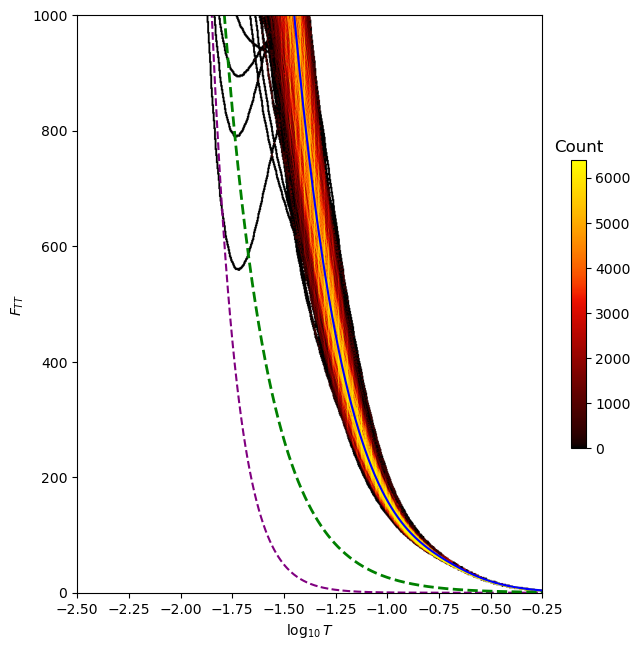

In [22]:
xrangemn, xrangemx = float(np.nanmin(df["logTemp"])), float(np.nanmax(df["logTemp"]))
yrangemn, yrangemx = float(np.nanmin(df["QFI"])),     float(np.nanmax(df["QFI"]))
yrangemn, yrangemx = 0,1000
xrangemn, xrangemx = -2.5,-0.25
#yrangemn, yrangemx = 0, 30000
# 2) Canvas (USE THIS ONE)
w, h, dpi = 750, 750, 100
cvs = ds.Canvas(plot_width=w, plot_height=h,
                x_range=(xrangemn, xrangemx),
                y_range=(yrangemn, yrangemx))

# 3) Aggregate (pick ONE)
# aggs = cvs.points(df2.dropna(subset=["logTemp","QFI"]), 'logTemp', 'QFI', agg=rd.count())
aggs = cvs.line(df, 'logTemp', 'QFI', agg=ds.count())
cmap = plt.cm.Spectral_r
img  = tf.spread(tf.shade(aggs,cmap=cc.cm.CET_L4), px=1)  # thicken strokes
# 4) Shade

#img = tf.shade(aggs, cmap=cmap)    # already a datashader Image
pil = img.to_pil()

# 5) Matplotlib render
fig = plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi)
ax = fig.add_subplot(111)
ax.imshow(pil, extent=[xrangemn, xrangemx, yrangemn, yrangemx],
          origin='upper', aspect='auto')
ax.grid(False)
ax.set_xlabel(r'$\log_{10} T$')
ax.set_ylabel('$F_{TT}$')

# 6) Colorbar (match the reduction)
vmin = float(np.nanmin(aggs.values))
vmax = float(np.nanmax(aggs.values))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cc.cm.CET_L4, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.5)
cbar.ax.set_title(r'Count')

ax.set_xlim(xrangemn, xrangemx)
ax.set_ylim(yrangemn, yrangemx)
#plt.savefig('QFI_12_12_sep_heatmap.png',bbox_inches="tight")

ax.plot(logTlist, qfi2ls_fitted,color = 'purple', ls = '--')
ax.plot(logTlist,line, color = 'green', label='QRM Energies', linestyle = '--',linewidth=2)
ax.plot(logTlist, avgqfi, color = 'blue')

plt.show()

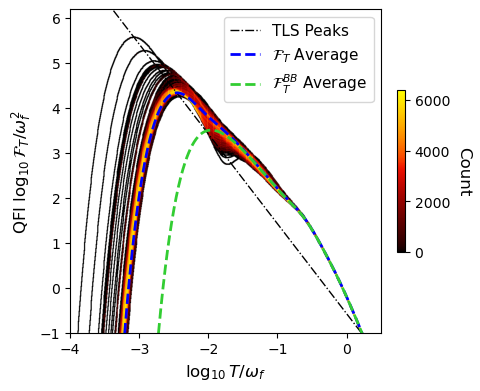

In [23]:
# 1) Ranges (use actual data)
xrangemn, xrangemx = float(np.nanmin(df["logTemp"])), float(np.nanmax(df["logTemp"]))
yrangemn, yrangemx = float(np.nanmin(df["logQFI"])),     float(np.nanmax(df["logQFI"]))
yrangemn, yrangemx = -1,6.2
xrangemn, xrangemx = -4,0.5
cmap=cc.cm.CET_L4
# 2) Canvas (USE THIS ONE)
w, h, dpi = 800, 640, 1000
cvs = ds.Canvas(plot_width=w, plot_height=h,
                x_range=(xrangemn, xrangemx),
                y_range=(yrangemn, yrangemx))

# 3) Aggregate (pick ONE)
# aggs = cvs.points(df2.dropna(subset=["logTemp","QFI"]), 'logTemp', 'QFI', agg=rd.count())
aggs = cvs.line(df, 'logTemp', 'logQFI', agg=rd.count())
cmap = plt.cm.Spectral_r
img  = tf.spread(tf.shade(aggs,cmap=cc.cm.CET_L4), px=1)  # thicken strokes
# 4) Shade

#img = tf.shade(aggs, cmap=cmap)    # already a datashader Image
pil = img.to_pil()

# 5) Matplotlib render
fig = plt.figure(figsize=(4.7, 3.8),layout='constrained')
ax = fig.add_subplot(111)
ax.imshow(pil, extent=[xrangemn, xrangemx, yrangemn, yrangemx],
          origin='upper', aspect='auto')
ax.grid(False)
ax.set_xlabel(r'$\log_{10} T/\omega_f$',fontsize='large')
ax.set_ylabel(r'QFI $\log_{10} \mathcal{F}_T/\omega_f^2$',fontsize='large')

# 6) Colorbar (match the reduction)
vmin = float(np.nanmin(aggs.values))
vmax = float(np.nanmax(aggs.values))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cc.cm.CET_L4, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.5)
cbar.set_label('Count', rotation=270, labelpad=15,fontsize='large')

ax.set_xlim(xrangemn, xrangemx)
ax.set_ylim(yrangemn, yrangemx)
#ax.plot(logTlist, logqfi2ls_fitted, label = r'2LS fitted', color = 'blueviolet', ls = '-', lw=2)
ax.plot(logTlist,logline, color = 'black', label=r'TLS Peaks', linestyle = '-.',linewidth=1)
ax.plot(logTlist, logavgqfi, label = r'$\mathcal{F}_T$ Average', color = 'blue', ls='--', lw=2)
#ax.plot(logTlist, logdarkbrightqfi, label = r'$\mathcal{F}^{BD}_T$ Average', color = 'red', ls='--', lw=2)
ax.plot(logTlist, logbrightbrightqfi, label = r'$\mathcal{F}^{BB}_T$ Average', color = 'limegreen', ls='--', lw=2)
ax.legend(fontsize=11)
plt.savefig('logQFI_brightsat_heatmap2.png',bbox_inches="tight", dpi=1000)
plt.show()

In [24]:
# 1) Ranges (use actual data)
xrangemn, xrangemx = float(np.nanmin(df["logTemp"])), float(np.nanmax(df["logTemp"]))
yrangemn, yrangemx = float(np.nanmin(df["logQFI"])),     float(np.nanmax(df["logQFI"]))
yrangemn, yrangemx = 0,6
xrangemn, xrangemx = -4,0
cmap=cc.cm.CET_L4
# 2) Canvas (USE THIS ONE)
w, h, dpi = 600, 600, 100
cvs = ds.Canvas(plot_width=w, plot_height=h,
                x_range=(xrangemn, xrangemx),
                y_range=(yrangemn, yrangemx))

# 3) Aggregate (pick ONE)
# aggs = cvs.points(df2.dropna(subset=["logTemp","QFI"]), 'logTemp', 'QFI', agg=rd.count())
aggs = cvs.line(df, 'logTemp', 'logQFI', agg=rd.mean('Xqratio'))
cmap = plt.cm.Spectral_r
img  = tf.spread(tf.shade(aggs,cmap=cc.cm.CET_L4), px=1)  # thicken strokes
# 4) Shade

#img = tf.shade(aggs, cmap=cmap)    # already a datashader Image
pil = img.to_pil()

# 5) Matplotlib render
fig = plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi)
ax = fig.add_subplot(111)
ax.imshow(pil, extent=[xrangemn, xrangemx, yrangemn, yrangemx],
          origin='upper', aspect='auto')
ax.grid(False)
ax.set_xlabel(r'$\log_{10} T$')
ax.set_ylabel(r'$\log_{10} QFI$')

# 6) Colorbar (match the reduction)
vmin = float(np.nanmin(aggs.values))
vmax = float(np.nanmax(aggs.values))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cc.cm.CET_L4, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.5)
cbar.set_label(r'$X_2/X_1$', rotation=0, labelpad=15)

ax.set_xlim(xrangemn, xrangemx)
ax.set_ylim(yrangemn, yrangemx)
ax.plot(logTlist, logqfi2ls_fitted, label = r'2LS fitted', color = 'blueviolet', ls = '-', lw=2)
ax.plot(logTlist,logline, color = 'black', label=r'2LS Peaks', linestyle = '--',linewidth=2)
ax.plot(logTlist, logavgqfi, label = r'Average QFI', color = 'blue', ls='-', lw=2)
ax.legend()
plt.savefig('logQFI_temp_heatmap_pcr.png',bbox_inches="tight")
plt.show()

KeyError: "['Xqratio'] not in index"